<a href="https://colab.research.google.com/github/azka-asif/flyrank-ML/blob/main/work/notebooks/capstone.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Capstone — mirrors your deployed research paper

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/azka-asif/flyrank-ML/blob/main/work/notebooks/capstone.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

In [2]:
%pip -q install duckdb huggingface_hub pandas numpy scikit-learn matplotlib

from google.colab import userdata
from huggingface_hub import login

import duckdb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

hf_token = userdata.get("HF_TOKEN")
login(token=hf_token)
con = duckdb.connect()
con.execute("SET enable_progress_bar = false")

try:
    con.execute("DROP SECRET hf")
except:
    pass

con.execute("""
    CREATE SECRET hf (
        TYPE huggingface,
        TOKEN ?
    )
""", [hf_token])

REL = "hf://datasets/FlyRank/internship-warehouse"
FACT = f"{REL}/fact_content_daily_performance"

print("Setup complete.")

Setup complete.


In [3]:
test_query = """
SELECT
    COUNT(*) AS rows,
    MIN(CAST(report_date AS DATE)) AS first_date,
    MAX(CAST(report_date AS DATE)) AS last_date
FROM read_parquet(
    'hf://datasets/FlyRank/internship-warehouse/fact_content_daily_performance/month=2026-03/*.parquet'
)
"""

con.execute(test_query).df()

,rows,first_date,last_date
0,9841378,2026-03-01,2026-03-31


## 1. Question

*The research question and the decision it supports.*

Can recent search-performance signals help identify content pages at the risk of a meaningful visibility decline, and can these signals be turned into a ranked queue for refresh review?

The main goal of this project is to find which content pages are most worth reviewing for a refresh. Looking through every page manually would take too much time, so I am using recent search performance data to rank the pages by priority. Each observation represents a content page in a particular month. The final result will be a ranked list with a score and a few reason codes showing why a page appears higher on the list. This is meant to help with prioritisation, not to automatically decide that a page needs to be changed.

## 2. Data

*Which release, which tables, date windows, what you excluded and why. Public-safe.*

For this project, I am using the FlyRank ML Internship warehouse, mainly the daily content performance data. I aggregate the daily data into monthly page-level observations so that I can compare how a page was doing in one period with what happened after it. I use data from December 2025 to June 2026, which gives enough history to create previous-month features and still keep a later month for evaluation. I only keep rows where Google Search Console data is available, and I remove pages with very low impressions because percentage changes can become misleading when the numbers are too small. Client and content IDs are only used for grouping pages correctly and are not included as model features. The analysis also avoids any client names, URLs, domains, raw queries, or other identifying information.

In [4]:
months = ["2025-12", "2026-01", "2026-02", "2026-03", "2026-04", "2026-05", "2026-06"]

files = []
for month in months:
    path = ("hf://datasets/FlyRank/internship-warehouse/" f"fact_content_daily_performance/month={month}/*.parquet")
    files.append(path)

query = f"""
WITH monthly_data AS (

    SELECT
        client_hash_id,
        content_hash_id,
        DATE_TRUNC('month', CAST(report_date AS DATE)) AS month,

        SUM(gsc_impressions) AS impressions,
        SUM(gsc_clicks) AS clicks,

        CASE
            WHEN SUM(gsc_impressions) > 0
            THEN 100.0 * SUM(gsc_clicks) / SUM(gsc_impressions)
            ELSE NULL
        END AS ctr,

        AVG(gsc_avg_position) AS avg_position,

        COUNT(DISTINCT CAST(report_date AS DATE))
            FILTER (WHERE gsc_impressions > 0)
            AS days_with_impressions

    FROM read_parquet({files})

    WHERE gsc_data_available = TRUE

    GROUP BY
        client_hash_id,
        content_hash_id,
        DATE_TRUNC('month', CAST(report_date AS DATE))
),

with_history AS (

    SELECT
        *,

        LAG(impressions, 1) OVER (
            PARTITION BY client_hash_id, content_hash_id
            ORDER BY month
        ) AS prev_impressions,

        LAG(impressions, 2) OVER (
            PARTITION BY client_hash_id, content_hash_id
            ORDER BY month
        ) AS prev2_impressions,

        LEAD(impressions, 1) OVER (
            PARTITION BY client_hash_id, content_hash_id
            ORDER BY month
        ) AS next_impressions,

        LAG(clicks, 1) OVER (
            PARTITION BY client_hash_id, content_hash_id
            ORDER BY month
        ) AS prev_clicks,

        LAG(ctr, 1) OVER (
            PARTITION BY client_hash_id, content_hash_id
            ORDER BY month
        ) AS prev_ctr,

        LAG(avg_position, 1) OVER (
            PARTITION BY client_hash_id, content_hash_id
            ORDER BY month
        ) AS prev_position

    FROM monthly_data
)

SELECT *
FROM with_history

WHERE month BETWEEN DATE '2026-02-01' AND DATE '2026-05-01'
AND impressions >= 100
AND prev_impressions IS NOT NULL
AND prev2_impressions IS NOT NULL
AND next_impressions IS NOT NULL

"""

df = con.execute(query).df()
print("Rows:", len(df))
print("Clients:", df["client_hash_id"].nunique())
print("Pages:", df["content_hash_id"].nunique())
print("\nRows per month:")
print(df["month"].value_counts().sort_index())
df.head()

Rows: 291517
Clients: 43
Pages: 105697

Rows per month:
month
2026-02-01    56128
2026-03-01    68397
2026-04-01    79108
2026-05-01    87884
Name: count, dtype: int64


,client_hash_id,content_hash_id,month,impressions,clicks,ctr,avg_position,days_with_impressions,prev_impressions,prev2_impressions,next_impressions,prev_clicks,prev_ctr,prev_position
0,client_08a6a72ff48e62c0,content_0129e58900e5ec36,2026-02-01,2482.0,10.0,0.402901,7.596952,28,7694.0,18183.0,4991.0,7.0,0.090980,8.604013
1,client_08a6a72ff48e62c0,content_0129e58900e5ec36,2026-03-01,4991.0,22.0,0.440793,8.494532,31,2482.0,7694.0,15860.0,10.0,0.402901,7.596952
2,client_08a6a72ff48e62c0,content_0129e58900e5ec36,2026-04-01,15860.0,69.0,0.435057,5.314050,30,4991.0,2482.0,5250.0,22.0,0.440793,8.494532
3,client_08a6a72ff48e62c0,content_08002aef95113462,2026-03-01,378.0,0.0,0.000000,64.957903,31,13.0,114.0,271.0,0.0,0.000000,26.472222
4,client_08a6a72ff48e62c0,content_08002aef95113462,2026-04-01,271.0,0.0,0.000000,49.101920,30,378.0,13.0,347.0,0.0,0.000000,64.957903


## 3. Methodology

*Assumptions, features, label definition, baseline, validation design, leakage checks.*

I framed this as a prediction and ranking problem. For each page, I used information from the current and previous months to see whether the page experiences a noticeable drop in search visibility in the following month.
I defined a future decline as the next month's impressions being at least 20% lower than the current month. This is only a proxy for identifying pages that may be worth reviewing. It doesm't mean that every declining page needs a refresh or that refreshing it would necessarily improve performance. The features mainly describe current performance and recent movement, including impressions, clicks, CTR, average position and changes from previous months. The final month is kept separate for testing so that the model is evaluated on a later period rather than on randomly mixed rows.

In [5]:
df["impression_change"] = ((df["impressions"] - df["prev_impressions"])/(df["prev_impressions"] + 1))
df["older_impression_change"] = ((df["prev_impressions"] - df["prev2_impressions"]) / (df["prev2_impressions"] + 1))

df["click_change"] = ((df["clicks"] - df["prev_clicks"]) / (df["prev_clicks"] + 1))
df["ctr_change"] = df["ctr"] - df["prev_ctr"]

df["position_change"] = (df["avg_position"] - df["prev_position"])

df["future_decline"] = (df["next_impressions"] < df["impressions"] * 0.80).astype(int)

features = [ "impressions", "clicks", "ctr", "avg_position", "days_with_impressions", "impression_change", "older_impression_change", "click_change", "ctr_change", "position_change"]
print("Decline rate:", round(df["future_decline"].mean(), 3))

df[features + ["future_decline"]].head()

Decline rate: 0.526


,impressions,clicks,ctr,avg_position,days_with_impressions,impression_change,older_impression_change,click_change,ctr_change,position_change,future_decline
0,2482.0,10.0,0.402901,7.596952,28,-0.677323,-0.576826,0.375000,0.311921,-1.007061,0
1,4991.0,22.0,0.440793,8.494532,31,1.010471,-0.677323,1.090909,0.037893,0.897580,0
2,15860.0,69.0,0.435057,5.314050,30,2.177284,1.010471,2.043478,-0.005737,-3.180482,1
3,378.0,0.0,0.000000,64.957903,31,26.071429,-0.878261,0.000000,0.000000,38.485681,1
4,271.0,0.0,0.000000,49.101920,30,-0.282322,26.071429,0.000000,0.000000,-15.855984,0


In [6]:
#using the earlier months for training
train = df[df["month"] < "2026-05-01"].copy()
#May data is used to predict what happens in June
test = df[df["month"] == "2026-05-01"].copy()

X_train = train[features]
y_train = train["future_decline"]
X_test = test[features]
y_test = test["future_decline"]

print("Training rows:", len(train))
print("Test rows:", len(test))
print("Training decline rate:", round(y_train.mean(), 3))
print("Test decline rate:", round(y_test.mean(), 3))

Training rows: 203633
Test rows: 87884
Training decline rate: 0.454
Test decline rate: 0.692


The share of pages that declined was noticeably higher in the final test period than in the earlier training months. This suggests that the May-June period was different from the earlier periods, so I kept the base rate visible when comparing model performance.

## 4. Results (vs baseline)

*Model vs baseline on the same split. The honest table.*

In [7]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score

# pages that were already losing impressions get a higher score
test["baseline_score"] = -test["impression_change"]

# logistic regression
log_model = Pipeline([("fill_missing", SimpleImputer(strategy="median")), ("scale", StandardScaler()), ("model", LogisticRegression(max_iter=1000, random_state=42))])
log_model.fit(X_train, y_train)
test["log_score"] = log_model.predict_proba(X_test)[:, 1]

# random forest
rf_model = Pipeline([("fill_missing", SimpleImputer(strategy="median")), ("model", RandomForestClassifier(n_estimators=150, max_depth=8, min_samples_leaf=30, random_state=42, n_jobs=-1))])

rf_model.fit(X_train, y_train)
test["rf_score"] = rf_model.predict_proba(X_test)[:, 1]
print("Models trained")

Models trained


In [8]:
def precision_at_k(y_true, scores, k=50):
    temp = pd.DataFrame({"actual": list(y_true),"score": list(scores)})
    top_k = temp.sort_values("score",ascending=False).head(k)
    return top_k["actual"].mean()

base_rate = y_test.mean()
baseline_p50 = precision_at_k(y_test,test["baseline_score"])
log_p50 = precision_at_k(y_test,test["log_score"])
rf_p50 = precision_at_k(y_test,test["rf_score"])

results = pd.DataFrame({
    "Method": ["Base rate","Simple baseline","Logistic regression", "Random forest"],

    "Precision@50": [base_rate, baseline_p50, log_p50,rf_p50],

    "ROC AUC": [
        None,

        roc_auc_score(y_test,test["baseline_score"]),

        roc_auc_score(y_test,test["log_score"]),

        roc_auc_score(y_test,test["rf_score"])]})

results

,Method,Precision@50,ROC AUC
0,Base rate,0.691832,NaN
1,Simple baseline,0.460000,0.492656
2,Logistic regression,0.420000,0.544992
3,Random forest,0.780000,0.570691


The random forest performed best for the main ranking metric. Out of the top 50 pages it ranked as highest risk, 78% declined in the following month, compared with a 69.2% decline rate across the full test set. The simple baseline and logistic regression both performed below the test base rate at the top of the ranking.The random forest's ROC AUC was 0.571, which is only a modest improvement over random ranking. This means the model seems more useful for prioritising a small number of pages for review than for accurately separating declining and non-declining pages across the entire dataset.

In [9]:
# feature importance from the random forest
rf = rf_model.named_steps["model"]
importance = pd.DataFrame({"feature": features, "importance": rf.feature_importances_ })

importance = importance.sort_values("importance", ascending=False)
importance

,feature,importance
4,days_with_impressions,0.462751
2,ctr,0.115856
9,position_change,0.085755
5,impression_change,0.067764
0,impressions,0.059688
1,clicks,0.059476
6,older_impression_change,0.057296
3,avg_position,0.055207
7,click_change,0.020598
8,ctr_change,0.015609


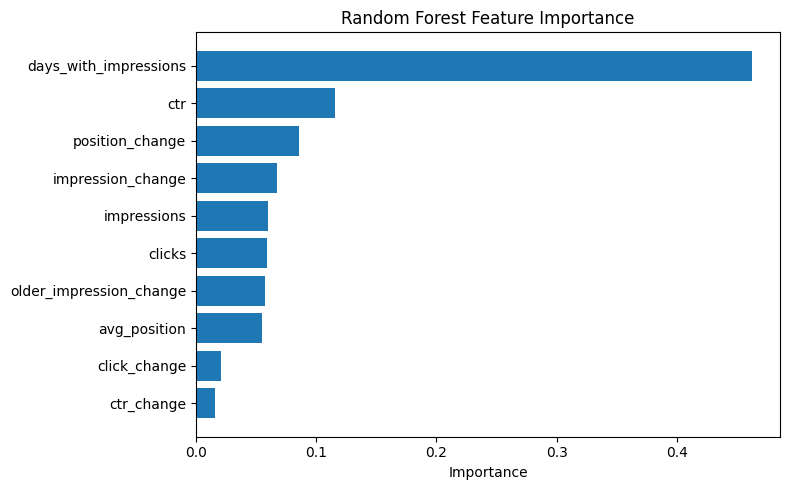

In [10]:
plt.figure(figsize=(8, 5))
plt.barh(importance["feature"], importance["importance"])
plt.gca().invert_yaxis()
plt.xlabel("Importance")
plt.title("Random Forest Feature Importance")
plt.tight_layout()
plt.show()

The model relied heavily on days_with_impressions, more than any other feature. Since this variable may also reflect differences between months and data coverage, I checked whether the model still performed well without it before using the model for the final ranking.

## 5. Limitations

*What this work cannot claim.*

The model predicts future declines in impressions, which is only being used as a proxy for pages that may be worth reviewing. A decline does not automatically mean that the content is outdated or that it needs to be refreshed.

The model also doesn't show that refreshing a page will improve its performance. Changes in search demand, competition, seasonality or search result layouts could also affect impressions. The results should therefore be used as decision support rather than as an automatic refresh rule.

Another limitation is that the test period had a noticeably higher decline rate than the training period. This means the May-June period may have behaved differently from earlier months, so the results may not generalise equally well to every future period. Also, the random forest relied heavily on days_with_impressions, which should be checked more carefully during validation before treating it as an important search signal.

In [11]:
decline_by_month = (df.groupby("month")["future_decline"].mean().round(3))

decline_by_month

,future_decline
month,
2026-02-01,0.196
2026-03-01,0.555
2026-04-01,0.551
2026-05-01,0.692


## 6. Ranked recommendations

*The action playbook output — the paper's recommendations section.*

Finally I turned the model output into something that could actually be used by an editor. I combined the Random Forest's estimated decline risk with the page's current search visibility to create an opportunity score. Pages with a high score are not automatically marked for rewriting; they are simply moved higher in the review queue. I also added a page status and short reason codes so that the ranking is easier to understand. For example, a page may be flagged because it has high visibility, a recent drop in impressions, worsening position, or low CTR.

In [12]:
test["decline_risk"] = test["rf_score"]

test["visibility_score"] = test["impressions"].rank(pct=True)

test["opportunity_score"] = (0.7 * test["decline_risk"] + 0.3 * test["visibility_score"])

def get_status(row):
    if (
        row["older_impression_change"] <= -0.20
        and row["impression_change"] >= 0.10
    ):
        return "recovering"

    elif row["impression_change"] <= -0.20:
        return "declining"

    elif row["impression_change"] >= 0.20:
        return "growing"

    else:
        return "stable"


test["status"] = test.apply(get_status, axis=1)
high_impressions = test["impressions"].quantile(0.75)
low_ctr = test["ctr"].quantile(0.25)


def get_reasons(row):
    reasons = []
    if row["impressions"] >= high_impressions:
        reasons.append("high visibility")

    if row["impression_change"] <= -0.20:
        reasons.append("recent impression drop")

    if row["position_change"] >= 2:
        reasons.append("position worsened")

    if row["ctr"] <= low_ctr:
        reasons.append("low CTR")

    if row["status"] == "recovering":
        reasons.append("recent recovery")

    if len(reasons) == 0:
        reasons.append("model risk")

    return ", ".join(reasons)

test["reason"] = test.apply(get_reasons, axis=1)

ranked_pages = test.sort_values("opportunity_score",ascending=False).copy()
ranked_pages["rank"] = range(1, len(ranked_pages) + 1)

ranked_pages["action"] = "monitor"
ranked_pages.loc[ranked_pages["rank"] <= 50, "action"] = "review first"
ranked_pages.loc[(ranked_pages["rank"] > 50) & (ranked_pages["rank"] <= 200), "action"] = "review"
recommendations = ranked_pages[["rank", "content_hash_id","status", "opportunity_score", "decline_risk", "impressions", "impression_change", "action", "reason"]]

recommendations.head(15)

,rank,content_hash_id,status,opportunity_score,decline_risk,impressions,impression_change,action,reason
148758,1,content_11bf4c33adea7bdc,declining,0.807967,0.726198,88175.0,-0.362536,review first,"high visibility, recent impression drop, posit..."
95288,2,content_09ba6b66c77bfe2a,declining,0.798163,0.737356,9124.0,-0.491530,review first,"high visibility, recent impression drop, posit..."
43017,3,content_ba98b9ba325cb149,declining,0.795286,0.709790,43637.0,-0.386719,review first,"high visibility, recent impression drop, posit..."
113947,4,content_5e20282db1d5b814,declining,0.793873,0.713145,21814.0,-0.758646,review first,"high visibility, recent impression drop, posit..."
175077,5,content_daf876f38ba13976,declining,0.793245,0.741973,6553.0,-0.439206,review first,"high visibility, recent impression drop, posit..."
280172,6,content_2b5ca79ecae24d89,declining,0.789722,0.738391,6317.0,-0.499009,review first,"high visibility, recent impression drop, posit..."
157675,7,content_fd288aae1ce88911,declining,0.789621,0.734606,6933.0,-0.271868,review first,"high visibility, recent impression drop, posit..."
266878,8,content_e23909f72d8ba18e,declining,0.789367,0.724108,9341.0,-0.617758,review first,"high visibility, recent impression drop, posit..."
134881,9,content_a45f23ca5a888d6a,declining,0.788131,0.720187,10050.0,-0.659404,review first,"high visibility, recent impression drop, posit..."
160114,10,content_da223b6fa1879f41,declining,0.787443,0.729478,7319.0,-0.404200,review first,"high visibility, recent impression drop, posit..."


The highest-ranked pages were mostly pages that were already showing a recent decline while still receiving meaningful search visibility. This was useful because it pushes pages with more potential impact toward the top of the review queue. The opportunity score is a prioritisation rule rather than a prediction made directly by the model, so the weights are only being used to organise the model output for editorial review.

## 7. Artifacts the paper embeds

*Generate/collect the charts and tables your deployed page will show.*

I kept three main visuals for the final paper. The first compares the baseline and models, the second shows which features the random forest relied on most, and the last shows how the decline rate changed across the different months. I kept the number of graphs small so that each one has a clear purpose.

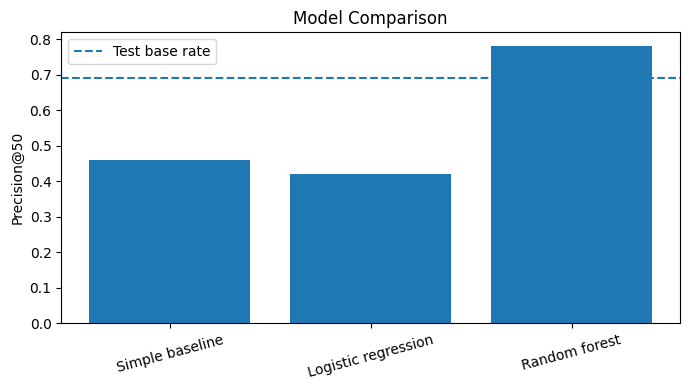

In [13]:
plot_data = results[results["Method"] != "Base rate"]
plt.figure(figsize=(7, 4))
plt.bar(plot_data["Method"], plot_data["Precision@50"])

plt.axhline(base_rate, linestyle="--", label="Test base rate")
plt.ylabel("Precision@50")
plt.title("Model Comparison")
plt.xticks(rotation=15)
plt.legend()

plt.tight_layout()
plt.show()

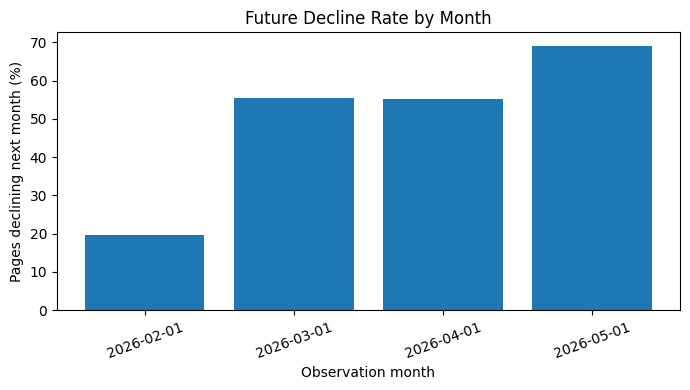

In [15]:
monthly_decline = (df.groupby("month")["future_decline"].mean() * 100)

plt.figure(figsize=(7, 4))
plt.bar(monthly_decline.index.astype(str), monthly_decline.values)

plt.ylabel("Pages declining next month (%)")
plt.xlabel("Observation month")
plt.title("Future Decline Rate by Month")

plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

## 5-minute demo outline

**1. Problem**
The project looks at how existing content pages can be prioritised for refresh review when there are too many pages to check manually.

**2. Data**
I used FlyRank search performance data and aggregated daily observations to the page-month level. The modelling data covers February to May 2026, with earlier months used to create historical features and the following month used as the outcome.

**3. Method**
I defined a future decline as a drop of at least 20% in impressions in the following month. I compared a simple trend baseline, logistic regression and random forest using a time-based test period.

**4. Main result**
The random forest performed best at the top of the ranking, with a Precision@50 of 78%, compared with a 69.2% decline rate in the full test set. Its overall ROC AUC was only 0.571, so I treat the model as a prioritisation tool rather than a strong general classifier.

**5. Output**
I converted the model's decline risk into a refresh opportunity ranking by also considering current search visibility. The final output gives editors a ranked review queue with simple reason codes.

## Short social post

I built a content refresh opportunity scoring model using the FlyRank ML Internship dataset. The goal was to rank existing pages that may be worth reviewing based on recent search performance rather than manually checking every page. A random forest gave the strongest top-of-list result, reaching 78% Precision@50 on the final time-based test period. I then turned the model output into a ranked review queue with reason codes to make the recommendations easier to interpret.

## Employer-facing summary

I built a page-level content refresh prioritisation system using real search performance data from the FlyRank ML Internship dataset. I compared a rule-based baseline with Logistic Regression and random forest under a time-based evaluation, then converted the strongest model into an interpretable ranked review queue. The project also includes leakage checks, limitations and reason codes so that the output is used as decision support rather than as an automatic content decision.

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.
- [ ] My deployed paper has **all 9 sections** — including the **Abstract** at the top and **Acknowledgments & data credit** (the https://flyrank.ai link) at the bottom.
- [ ] **ML-12 done in this notebook's closing cells:** 5-minute demo outline + a social-post cut + a 3-sentence employer-facing summary.
